In [1]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
print(f"GPU Available: {torch.cuda.get_device_name(0)}")
print(f"Memory Free: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")
print(f"Memory Total: {torch.cuda.mem_get_info()[1]/1024**3:.2f} GB")

GPU Available: Tesla T4
Memory Free: 14.46 GB
Memory Total: 14.56 GB


In [2]:
!pip install transformers torch scikit-learn pandas emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.3 MB/s eta 0:00:00


In [4]:
import pandas as pd
df = pd.read_csv("/content/daraz-code-mixed-product-reviews.csv")
df

,Sentiments,Reviews
0,negative,Stuff and design was totally changed. cheap qu...
1,positive,"i got my parxel before time,sorry for late rev..."
2,positive,So far so good..... Bought it only because it ...
3,neutral,Received as described but not suitable such ha...
4,positive,Received on time and in a safely packed box. T...
...,...,...
16985,negative,It is doing nothing. I have wasted my money an...
16986,positive,Bht he achi prdct h Jo cheez dekhi whi mili ma...
16987,neutral,product quality is not very good but working o...
16988,positive,Very soft and cozy product perfect travel part...


In [5]:
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
df['Label'] = df['Sentiments'].map(sentiment_mapping)
print(df['Label'].value_counts())
print(df.shape)

Label
2    10167
0     4362
1     2461
Name: count, dtype: int64
(16990, 3)


In [6]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

df_pos = df[df['Label'] == 2]
df_neg = df[df['Label'] == 0]
df_neu = df[df['Label'] == 1]

df_neg_up = resample(df_neg, replace=True, n_samples=len(df_pos), random_state=42)
df_neu_up = resample(df_neu, replace=True, n_samples=len(df_pos), random_state=42)

df_balanced = pd.concat([df_pos, df_neg_up, df_neu_up]).sample(frac=1, random_state=42).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['Reviews'].astype(str),
    df_balanced['Label'],
    test_size=0.2, random_state=42, stratify=df_balanced['Label']
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 24400 | Test: 6101


In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')
print("Tokenizer loaded ✅")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Tokenizer loaded ✅


In [8]:
import re
import emoji
from torch.utils.data import Dataset
def preprocess(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = emoji.demojize(text, delimiters=(" ", " "))
    roman_urdu_map = {
    # existing
    r'\bbht\b': 'bohot', r'\bbhut\b': 'bohot', r'\bnhi\b': 'nahi',
    r'\bthk\b': 'theek', r'\bthik\b': 'theek', r'\bkr\b': 'kar',
    r'\bphr\b': 'phir', r'\bmje\b': 'mujhe', r'\bor\b': 'aur',
    r'\bachi\b': 'acha', r'\bachha\b': 'acha',

    # neutral fixes
    r'\btheek theek\b': 'average',
    r'\btheek\b': 'average',
    r'\btheak\b': 'average',
    r'\bna acha na bura\b': 'average',
    r'\bkhas nahi\b': 'not special',
    r'\bkuch khas nahi\b': 'nothing special',
    r'\bkuch nahi\b': 'nothing special',
    r'\bdrhi\b': 'delivery',
    r'\bpacking\b': 'packaging',
    r'\bkam se kam\b': 'atleast',
    r'\bthora\b': 'thoda',
    r'\bzyada\b': 'zyada',
    r'\bkaam\b': 'kaam',
    r'\bwaisa\b': 'same',
    r'\bjaisa\b': 'as expected',

    r'\bbakwaas\b': 'terrible',
    r'\bbaqwas\b': 'terrible',
    r'\bbkwas\b': 'terrible',
    r'\bbkws\b': 'terrible',
    r'\bbekar\b': 'useless',
    r'\bwaste\b': 'waste',
    r'\bkharab\b': 'bad quality',
    r'\bghатia\b': 'terrible',
    r'\bghatia\b': 'terrible',
    r'\bfaltu\b': 'useless',
    r'\bnakli\b': 'fake',
    r'\bdhoka\b': 'fraud',
    r'\bloot\b': 'scam',

    r'\bbilkul sahi\b': 'perfectly fine',
    r'\bbilkul acha\b': 'very good',
    r'\bbilkul theek\b': 'perfectly fine',
    r'\bkhush hun\b': 'happy satisfied',
    r'\bpehle bhi\b': 'previously also',
    r'\bdobara lunga\b': 'will buy again',
    r'\brecommend\b': 'recommend',
}
    for pattern, replacement in roman_urdu_map.items():
        text = re.sub(pattern, replacement, text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = preprocess(self.texts[idx])  # ← added preprocessing
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ReviewDataset(X_train, y_train, tokenizer)
test_dataset = ReviewDataset(X_test, y_test, tokenizer)
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 24400 | Test: 6101


In [9]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-multilingual-cased',
    num_labels=3
)
print("Model loaded ✅")

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded ✅


In [10]:
from torch.utils.data import DataLoader
from torch.optim import AdamW  # changed this line
from transformers import get_scheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

model = model.to(device)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

optimizer = AdamW(model.parameters(), lr=2e-5)

num_epochs = 3
scheduler = get_scheduler("linear", optimizer=optimizer,
                          num_warmup_steps=0,
                          num_training_steps=num_epochs * len(train_loader))
print("Setup done ✅")

Using: cuda
Setup done ✅


In [11]:
from tqdm import tqdm

model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

Epoch 1: 100%|██████████| 763/763 [17:01<00:00,  1.34s/it]


Epoch 1 Loss: 0.4514


Epoch 2: 100%|██████████| 763/763 [17:00<00:00,  1.34s/it]


Epoch 2 Loss: 0.2213


Epoch 3: 100%|██████████| 763/763 [16:59<00:00,  1.34s/it]

Epoch 3 Loss: 0.1305


In [12]:
from sklearn.metrics import classification_report
import numpy as np

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds,
      target_names=['negative','neutral','positive']))

Evaluating: 100%|██████████| 191/191 [01:33<00:00,  2.05it/s]

              precision    recall  f1-score   support

    negative       0.97      0.97      0.97      2033
     neutral       0.92      0.97      0.95      2034
    positive       0.97      0.92      0.95      2034

    accuracy                           0.95      6101
   macro avg       0.96      0.95      0.95      6101
weighted avg       0.96      0.95      0.95      6101



In [15]:
import os
from google.colab import drive

drive.mount('/content/drive')
output_dir = '/content/drive/MyDrive/SentivaAI/mbert_final'
os.makedirs(output_dir, exist_ok=True)
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)
print(f"Model and tokenizer saved to {output_dir}")

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/SentivaAI/mbert_final


In [16]:
print(os.listdir('/content/drive/MyDrive/SentivaAI/mbert_final'))

['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']


Overall Accuracy: 95.46%
Macro F1: 95.46%
Weighted F1: 95.46%
              precision    recall  f1-score   support

    negative       0.97      0.97      0.97      2033
     neutral       0.92      0.97      0.95      2034
    positive       0.97      0.92      0.95      2034

    accuracy                           0.95      6101
   macro avg       0.96      0.95      0.95      6101
weighted avg       0.96      0.95      0.95      6101



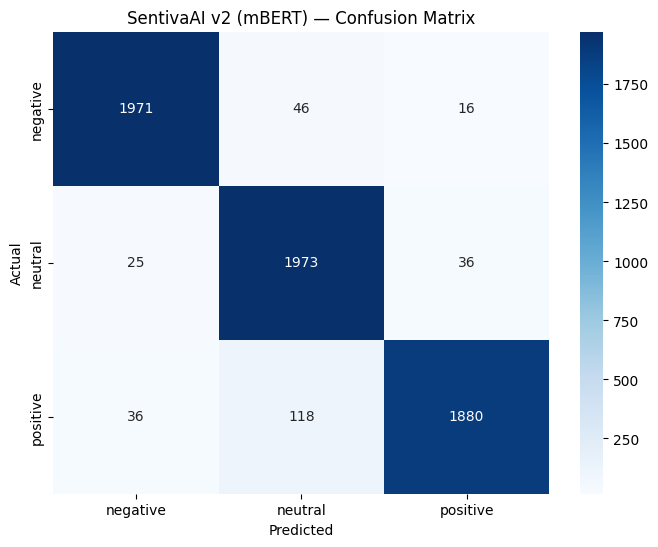


ROC-AUC Score: 98.94%


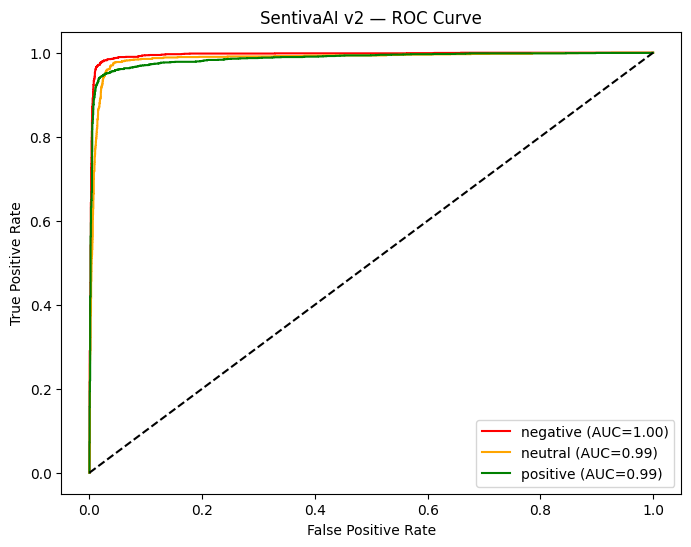

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score)
from sklearn.preprocessing import label_binarize
import numpy as np

# Basic metrics
print("="*50)
print(f"Overall Accuracy: {accuracy_score(all_labels, all_preds)*100:.2f}%")
print(f"Macro F1: {f1_score(all_labels, all_preds, average='macro')*100:.2f}%")
print(f"Weighted F1: {f1_score(all_labels, all_preds, average='weighted')*100:.2f}%")
print("="*50)
print(classification_report(all_labels, all_preds,
      target_names=['negative','neutral','positive']))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.title('SentivaAI v2 (mBERT) — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_v2.png')
plt.show()

# ROC-AUC
y_bin = label_binarize(all_labels, classes=[0,1,2])
# get probabilities
model.eval()
all_probs = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)
roc_auc = roc_auc_score(y_bin, all_probs, multi_class='ovr', average='macro')
print(f"\nROC-AUC Score: {roc_auc*100:.2f}%")

# Per class ROC curve
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(8,6))
colors = ['red','orange','green']
labels = ['negative','neutral','positive']
for i, (color, label) in enumerate(zip(colors, labels)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], all_probs[:,i])
    plt.plot(fpr, tpr, color=color, label=f'{label} (AUC={auc(fpr,tpr):.2f})')

plt.plot([0,1],[0,1],'k--')
plt.title('SentivaAI v2 — ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('roc_curve_v2.png')
plt.show()

In [22]:
long_reviews = [
    # Long negative
    "maine ye product order kiya tha bohot umeed ke saath lekin jab mila toh bilkul bekar nikla, quality bohot kharab thi, packaging bhi toot ke aayi, seller ne koi response nahi diya, bohot bura experience tha, dobara nahi lunga",

    # Long positive
    "bohot acha product hai yaar, maine pehle bhi isi seller se order kiya tha aur har baar quality acha hota hai, delivery bhi time pe aayi, packaging bohot secure thi, price bhi reasonable hai, highly recommend karta hun sabko",

    # Long neutral/mixed
    "product theek hai lekin price thoda zyada lagta hai, delivery time pe aayi jo acha laga, lekin quality expected se thodi kam thi, packaging average thi, seller ka response bhi slow tha, overall theek theek experience raha",

    # Very mixed
    "kuch cheezein bohot acha thi jaise delivery fast thi aur packaging secure thi, lekin product ki quality se thoda disappointed tha, color bhi photo se alag nikla, price ke hisaab se theek hai lekin better expect karta tha",

    # Long negative with English mix
    "worst experience ever, product bilkul fake nikla, photos mein kuch aur tha aur mila kuch aur, seller ko message kiya toh unhone block kar diya, daraz se complain ki toh unka bhi koi response nahi, total waste of money aur time",
]

for review in long_reviews:
    clean = preprocess(review)
    inputs = tokenizer(clean, return_tensors='pt',
                      max_length=256, truncation=True, padding='max_length')
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)[0]
        pred = torch.argmax(outputs.logits, dim=1).item()

    label_map = {0: '🔴 Negative', 1: '🟡 Neutral', 2: '🟢 Positive'}
    print(f"REVIEW: '{review[:60]}...'")
    print(f"→ {label_map[pred]} | N:{probs[0]*100:.1f}% U:{probs[1]*100:.1f}% P:{probs[2]*100:.1f}%")
    print()

REVIEW: 'maine ye product order kiya tha bohot umeed ke saath lekin j...'
→ 🔴 Negative | N:98.6% U:1.1% P:0.3%

REVIEW: 'bohot acha product hai yaar, maine pehle bhi isi seller se o...'
→ 🟢 Positive | N:0.2% U:2.2% P:97.7%

REVIEW: 'product theek hai lekin price thoda zyada lagta hai, deliver...'
→ 🟡 Neutral | N:0.7% U:98.8% P:0.4%

REVIEW: 'kuch cheezein bohot acha thi jaise delivery fast thi aur pac...'
→ 🟡 Neutral | N:0.3% U:97.6% P:2.1%

REVIEW: 'worst experience ever, product bilkul fake nikla, photos mei...'
→ 🔴 Negative | N:99.7% U:0.1% P:0.2%

